In [1]:
import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("data/raw/7282_1.csv")

# giữ rating hợp lệ
df = df[df["reviews.rating"].between(1,5)]

# giảm dữ liệu để chạy nhanh
df = df.sample(5000, random_state=42)

df.head()

,address,categories,city,country,latitude,longitude,name,postalCode,province,reviews.date,reviews.dateAdded,reviews.doRecommend,reviews.id,reviews.rating,reviews.text,reviews.title,reviews.userCity,reviews.username,reviews.userProvince
5342,480 King St,"Hotels,Hotel",Alexandria,US,38.804740,-77.044550,"The Alexandrian, Autograph Collection",22314,VA,2014-06-11T00:00:00Z,2017-04-20T01:34:00Z,NaN,NaN,4.0,Shame the pool was closed at a time it was adv...,Good location,NaN,jellybean,England
19665,999 N Second St,"Hotels,Hotel",Saint Louis,US,38.633021,-90.184037,Four Seasons Hotel St. Louis,63102,MO,2015-12-24T00:00:00Z,2016-03-31T03:49:58Z,NaN,NaN,5.0,"I stayed here for a mom's weekend away, and it...",Best Spa in Town,Poteau,trisheric99,OK
7924,1100 N Mississippi Ave,"Bed & Breakfasts,Hotels,Inns,E-Commerce",Ada,US,34.786299,-96.669808,Raintree Inn,74820,Pontotoc,2015-05-31T00:00:00Z,2017-02-10T08:01:57Z,NaN,NaN,4.0,"Clean, spacious rooms, great service, great ra...",Highly recommend staying here,Drumright,Paul B,OK
35394,1350 W Atlantic St,"Wedding Sites,Hotels,Hotels & Motels,Meeting F...",Emporia,US,36.706690,-77.559910,Holiday Inn Express Hotel & Suites Emporia,23847,VA,2015-03-15T00:00:00Z,2016-11-17T15:08:43Z,NaN,NaN,5.0,The hotel itself was nice but we were disappoi...,Hotel,NaN,carole,NaN
15707,5200 Fashion Square Blvd,Hotels,Saginaw,US,43.484180,-83.969070,Fairfield Inn Saginaw,48604,MI,2014-03-28T00:00:00Z,2016-11-10T19:30:31Z,NaN,NaN,5.0,Took 30+ teenage girls to a Winterguard compet...,Nice,Castle Rock,A Traveler,CO


In [3]:
df = df.dropna(subset=["reviews.text","reviews.rating"])

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+","",text)
    text = re.sub(r"[^a-z\s]","",text)
    return text

df["clean_text"] = df["reviews.text"].apply(clean_text)

In [5]:
y_rating = df["reviews.rating"]

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)

X = vectorizer.fit_transform(df["clean_text"])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_rating,
    test_size=0.2,
    random_state=42
)

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_rating,
    test_size=0.2,
    random_state=42
)

In [9]:
model = Ridge()

model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [10]:
pred = model.predict(X_test)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=500,
    stop_words="english"
)

X = tfidf.fit_transform(df["clean_text"])

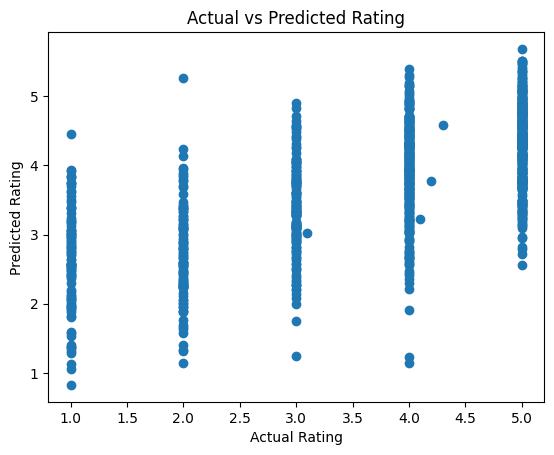

In [12]:
plt.scatter(y_test, pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Rating")

plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.7652985122806482
RMSE: 0.9767712075231555


In [14]:
# Ridge regression was used to predict hotel review ratings from TF-IDF features.
# MAE measures the average prediction error.
# RMSE penalizes larger errors.